In [7]:
import pandas as pd
final_df=pd.read_csv("../final_titanic_dataset.csv")

In [8]:
#handling Data normalization
#1 Min_Max Normalization
min_fare=final_df.Fare.min()
max_fare=final_df.Fare.max()

In [9]:
norm_fare=(final_df.Fare-min_fare)/(max_fare-min_fare)

In [10]:
norm_fare.describe()

count    714.000000
mean       0.067719
std        0.103291
min        0.000000
25%        0.015713
50%        0.030726
75%        0.065144
max        1.000000
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

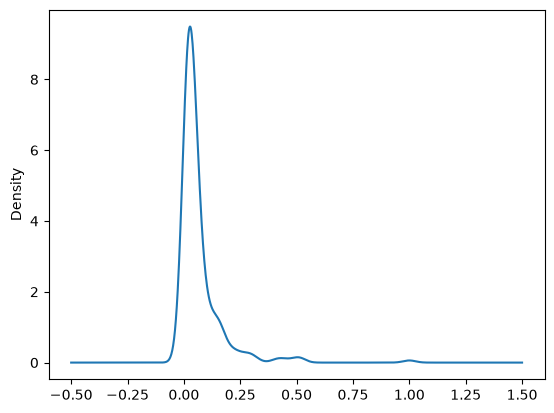

In [11]:
norm_fare.plot(kind="kde")

In [12]:
from sklearn.preprocessing import MinMaxScaler
mm_scaler=MinMaxScaler()
scaled_data=mm_scaler.fit_transform(final_df[["Fare"]])

In [13]:
scaled_data

array([[0.01415106],
       [0.13913574],
       [0.01546857],
       [0.1036443 ],
       [0.01571255],
       [0.10122886],
       [0.04113566],
       [0.02173075],
       [0.05869429],
       [0.03259623],
       [0.05182215],
       [0.01571255],
       [0.06104473],
       [0.01533038],
       [0.03122992],
       [0.05684821],
       [0.03513366],
       [0.05074862],
       [0.02537431],
       [0.01567195],
       [0.06929139],
       [0.04113566],
       [0.06126432],
       [0.51334181],
       [0.0541074 ],
       [0.02049464],
       [0.16038672],
       [0.10149724],
       [0.01571255],
       [0.03513366],
       [0.02194234],
       [0.01849397],
       [0.04098927],
       [0.08115719],
       [0.01537917],
       [0.03474329],
       [0.07746484],
       [0.01522459],
       [0.14976542],
       [0.05074862],
       [0.12097534],
       [0.02049464],
       [0.01411046],
       [0.05416439],
       [0.0915427 ],
       [0.01411046],
       [0.1561496 ],
       [0.162

In [14]:
#Z-Score Normalization/StandardScalar
mean_fare=final_df.Fare.mean()
std_fare=final_df.Fare.std()


In [15]:
norm_fare=(final_df.Fare-mean_fare)/std_fare

In [16]:
norm_fare.describe()

count    7.140000e+02
mean    -4.975789e-17
std      1.000000e+00
min     -6.556163e-01
25%     -5.034968e-01
50%     -3.581481e-01
75%     -2.493463e-02
max      9.025781e+00
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

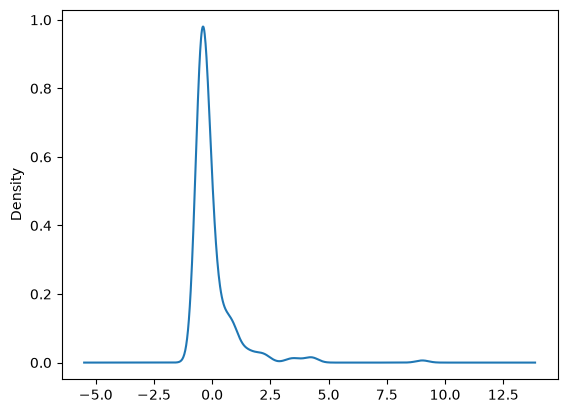

In [17]:
norm_fare.plot(kind="kde")

In [18]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()

In [22]:
norm_data=std_scaler.fit_transform(final_df[["Fare"]])

<Axes: >

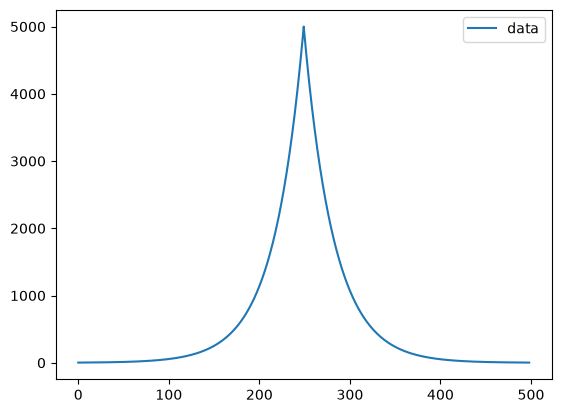

In [34]:
#log transformation
import numpy as np

peak = 5 * 10e2      # 500000
n = 250              # points per side

k = np.log(peak)
growth = np.exp(np.linspace(1, k, n))
decay = np.exp(np.linspace(k, 1, n))
data = np.concatenate([growth, decay[1:]])

pd.DataFrame(data, columns=["data"]).plot(kind="line")


In [24]:
import numpy as np

In [35]:
fif=np.nan_to_num(np.log(final_df.Fare),neginf=0.0)

f:\github\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [36]:
fif.plot(kind="kde")

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

<Axes: ylabel='Density'>

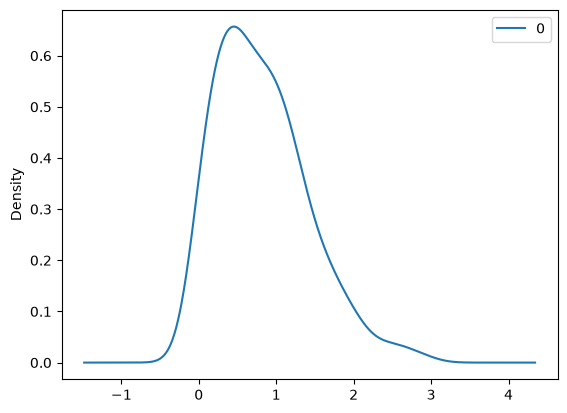

In [37]:
#power Transformation
from scipy.stats import skewnorm
data=pd.DataFrame(skewnorm.rvs(25,size=200))
data.plot(kind="kde")

In [43]:
pow_transformer = lambda series, pow_factor: (
    np.sign(series) * np.power(np.abs(series), pow_factor)
)

trans_data = pow_transformer(data, 0.7)


<Axes: ylabel='Density'>

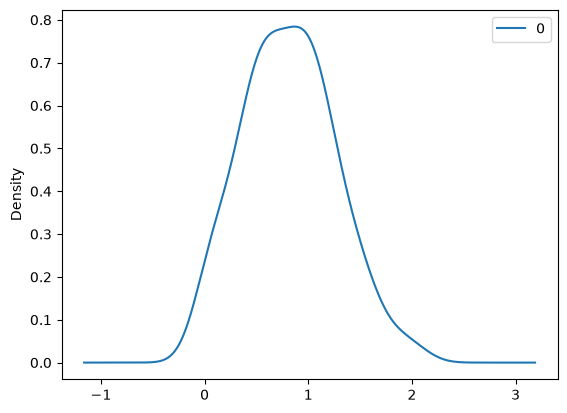

In [44]:
trans_data.plot.kde()